In [1]:
import os, time
from pathlib import Path
import torch
import psutil
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown

%matplotlib inline

display(Markdown("## Part 0 — Setup"))
display(Markdown("_Imports, helpers, RAM tracker, and the model ID. Nothing is downloaded or loaded yet._"))

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

CATEGORY_COLORS = {
    "weights":          "#d62728",
    "tokenizer":        "#2ca02c",
    "model-config":     "#1f77b4",
    "metadata/license": "#9467bd",
    "other":            "#7f7f7f",
}

PROC = psutil.Process(os.getpid())
def ram_mb(): return PROC.memory_info().rss / (1024 ** 2)

def fmt_size(b):
    if b < 1024:        return f"{b} B"
    if b < 1024**2:     return f"{b/1024:.2f} KB"
    if b < 1024**3:     return f"{b/1024**2:.2f} MB"
    return f"{b/1024**3:.2f} GB"

STAGE_LOG = []

class Stage:
    """Reusable timing + RAM tracker. Use in every level."""
    def __init__(self, name, reads=""):
        self.name, self.reads = name, reads
    def __enter__(self):
        print(f"▶ {self.name}")
        if self.reads: print(f"  reads: {self.reads}")
        self.ram_start = ram_mb()
        self.t_start = time.time()
        return self
    def __exit__(self, *a):
        dt = time.time() - self.t_start
        ram_end = ram_mb()
        delta = ram_end - self.ram_start
        STAGE_LOG.append({
            "stage":         self.name,
            "reads":         self.reads,
            "ram_before_MB": round(self.ram_start, 1),
            "ram_after_MB":  round(ram_end, 1),
            "ram_delta_MB":  round(delta, 1),
            "time_s":        round(dt, 2),
        })
        print(f"  ✓ {dt:.2f}s   ΔRAM +{delta:.1f} MB   total {ram_end:.1f} MB\n")

MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@                PART 00: SETUP COMPLETE                   @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("========== ENVIRONMENT ==========")
print("model id   :", MODEL_ID)
print("torch ver  :", torch.__version__)
print("cuda avail :", torch.cuda.is_available())
print("baseline RAM (notebook only) :", f"{ram_mb():.1f} MB")
print("=================================")

## Part 0 — Setup

_Imports, helpers, RAM tracker, and the model ID. Nothing is downloaded or loaded yet._

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@                PART 00: SETUP COMPLETE                   @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
========== ENVIRONMENT ==========
model id   : meta-llama/Llama-3.2-1B-Instruct
torch ver  : 2.12.0+cpu
cuda avail : False
baseline RAM (notebook only) : 313.7 MB


## Part 1 — Download stage

_Where do files land on disk? What is fetched and in what order?_

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@               PART 01: DOWNLOAD STAGE                    @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


**Cache before:** hit=`False`

========== STEP 1: CACHE CHECK ==========
cache hit : False

========== STEP 2: SNAPSHOT DOWNLOAD ==========
▶ snapshot_download
  reads: huggingface hub


...

  ✓ 41.26s   ΔRAM +468.5 MB   total 793.9 MB

local path : /home/ubuntu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6



**Cache layout**
- root: `/home/ubuntu/.cache/huggingface/hub`
- snapshot: `/home/ubuntu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`
- relative: `models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`


**Files on disk (small → large = fetch order)**

,filename,category,size
#,,,
1,generation_config.json,model-config,189 B
2,special_tokens_map.json,tokenizer,296 B
3,config.json,model-config,877 B
4,.gitattributes,other,1.48 KB
5,USE_POLICY.md,metadata/license,5.88 KB
6,LICENSE.txt,metadata/license,7.53 KB
7,README.md,metadata/license,40.76 KB
8,tokenizer_config.json,tokenizer,53.25 KB
9,tokenizer.json,tokenizer,8.66 MB



========== STEP 3: FILES ON DISK ==========
file count : 10
total size : 2.31 GB
  model-config              189 B  generation_config.json
  tokenizer                 296 B  special_tokens_map.json
  model-config              877 B  config.json
  other                   1.48 KB  .gitattributes
  metadata/license        5.88 KB  USE_POLICY.md
  metadata/license        7.53 KB  LICENSE.txt
  metadata/license       40.76 KB  README.md
  tokenizer              53.25 KB  tokenizer_config.json
  tokenizer               8.66 MB  tokenizer.json
  weights                 2.30 GB  model.safetensors


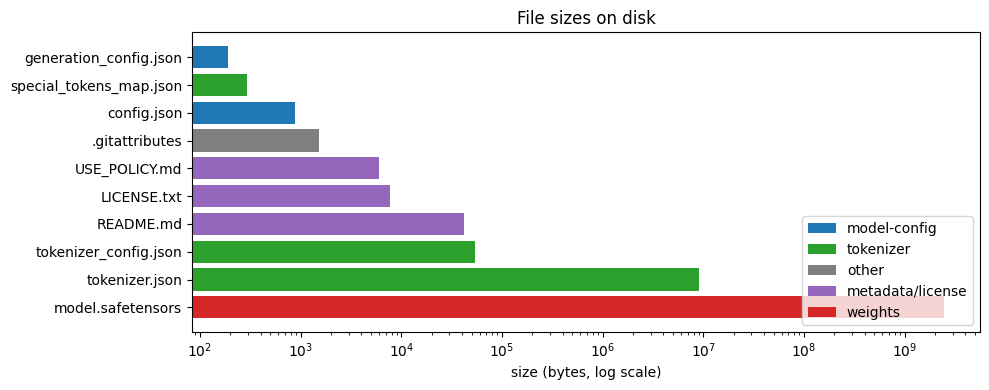


**Summary** — files: `10`, total: `2.31 GB`, fresh: `True`


In [2]:
display(Markdown("## Part 1 — Download stage"))
display(Markdown("_Where do files land on disk? What is fetched and in what order?_"))

from huggingface_hub import snapshot_download, scan_cache_dir

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@               PART 01: DOWNLOAD STAGE                    @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

def cache_info(model_id):
    try:
        for r in scan_cache_dir().repos:
            if r.repo_id == model_id:
                return True, r.size_on_disk
    except Exception: pass
    return False, 0

cached_before, size_before = cache_info(MODEL_ID)
display(Markdown(f"**Cache before:** hit=`{cached_before}`" +
                 (f", size=`{fmt_size(size_before)}`" if cached_before else "")))

print("========== STEP 1: CACHE CHECK ==========")
print("cache hit :", cached_before)
if cached_before:
    print("cached size :", fmt_size(size_before))
print("=========================================")

print()
print("========== STEP 2: SNAPSHOT DOWNLOAD ==========")
with Stage("snapshot_download", reads="huggingface hub"):
    local_path = snapshot_download(repo_id=MODEL_ID)
print("local path :", local_path)
print("===============================================")

hf_root = Path(os.path.expanduser("~/.cache/huggingface/hub"))
display(Markdown(f"""
**Cache layout**
- root: `{hf_root}`
- snapshot: `{local_path}`
- relative: `{Path(local_path).relative_to(hf_root)}`
"""))

def categorize(name):
    n = name.lower()
    if n.endswith((".safetensors", ".bin")):                return "weights"
    if n in ("config.json", "generation_config.json"):      return "model-config"
    if "tokenizer" in n or n == "special_tokens_map.json":  return "tokenizer"
    if n.endswith((".md", ".txt")):                         return "metadata/license"
    return "other"

rows = []
for f in os.listdir(local_path):
    full = os.path.join(local_path, f)
    if os.path.isfile(full) or os.path.islink(full):
        s = os.path.getsize(full)
        rows.append({"filename": f, "category": categorize(f),
                     "size_bytes": s, "size": fmt_size(s)})

df_files = pd.DataFrame(rows).sort_values("size_bytes").reset_index(drop=True)
df_files.index = range(1, len(df_files) + 1)
df_files.index.name = "#"

display(Markdown("**Files on disk (small → large = fetch order)**"))
display(df_files[["filename", "category", "size"]])

print()
print("========== STEP 3: FILES ON DISK ==========")
print(f"file count : {len(df_files)}")
print(f"total size : {fmt_size(df_files['size_bytes'].sum())}")
for _, row in df_files.iterrows():
    print(f"  {row['category']:18s} {row['size']:>12s}  {row['filename']}")
print("===========================================")

# horizontal bar — file sizes (log scale)
fig, ax = plt.subplots(figsize=(10, max(3, len(df_files) * 0.4)))
ax.barh(df_files["filename"], df_files["size_bytes"],
        color=[CATEGORY_COLORS[c] for c in df_files["category"]])
ax.set_xscale("log")
ax.set_xlabel("size (bytes, log scale)")
ax.set_title("File sizes on disk")
ax.invert_yaxis()
cats_present = df_files["category"].unique()
ax.legend(handles=[Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in cats_present],
          loc="lower right")
plt.tight_layout(); plt.show()

# # pie — disk usage by category
# cat_sizes = df_files.groupby("category")["size_bytes"].sum().sort_values(ascending=False)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.pie(cat_sizes.values, labels=cat_sizes.index,
#        colors=[CATEGORY_COLORS[c] for c in cat_sizes.index],
#        autopct=lambda p: f"{p:.1f}%\n({fmt_size(p * cat_sizes.sum() / 100)})",
#        startangle=90)
# ax.set_title("Disk usage by category"); plt.tight_layout(); plt.show()

total = df_files["size_bytes"].sum()
display(Markdown(f"""
**Summary** — files: `{len(df_files)}`, total: `{fmt_size(total)}`, fresh: `{not cached_before}`
"""))

## Part 2 — Load into RAM stage

_Disk → RAM. What is read, in what order, how much memory is consumed?_

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@              PART 02: LOAD INTO RAM STAGE                @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


**Baseline RAM (before model load):** `856.0 MB`

========== STEP 1: BASELINE RAM ==========
RAM before any load : 856.0 MB

========== STEP 2: LOAD TOKENIZER ==========
reads : tokenizer.json, tokenizer_config.json, special_tokens_map.json
▶ load tokenizer
  reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json


...

  ✓ 2.57s   ΔRAM +197.4 MB   total 1053.3 MB

tokenizer class : TokenizersBackend
vocab size      : 128000

========== STEP 3: LOAD MODEL CONFIG ==========
reads : config.json
▶ load model config
  reads: config.json
  ✓ 0.03s   ΔRAM +0.0 MB   total 1053.3 MB

config class : LlamaConfig
architecture : LlamaForCausalLM

========== STEP 4: LOAD MODEL WEIGHTS ==========
reads : *.safetensors
▶ load model weights
  reads: *.safetensors


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  ✓ 1.61s   ΔRAM +2366.9 MB   total 3420.2 MB

model class :  LlamaForCausalLM
model dtype :  torch.float16
model device:  cpu


**Step-by-step load log**

,stage,reads,ram_before_MB,ram_after_MB,ram_delta_MB,time_s
0,load tokenizer,"tokenizer.json, tokenizer_config.json, special...",856.0,1053.3,197.4,2.57
1,load model config,config.json,1053.3,1053.3,0.0,0.03
2,load model weights,*.safetensors,1053.3,3420.2,2366.9,1.61


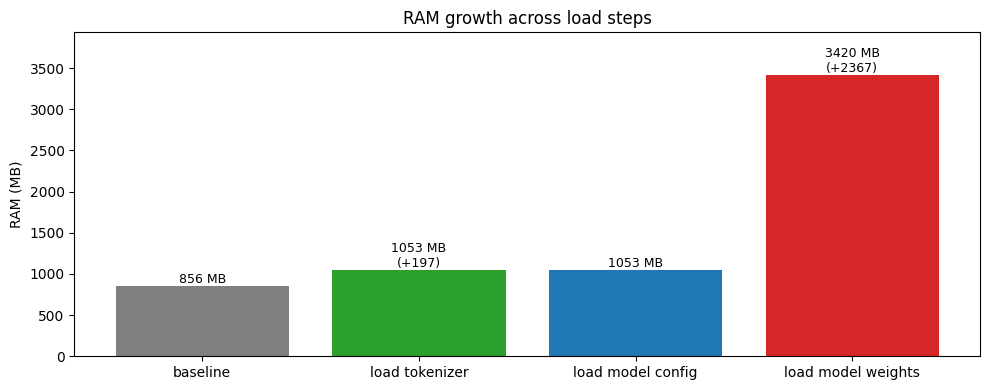

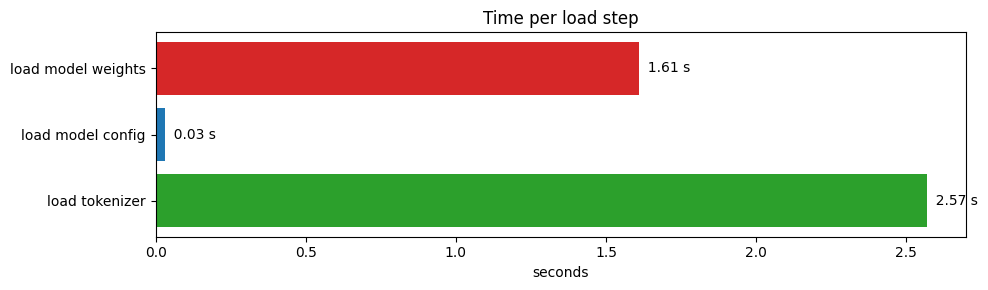


========== STEP 5: MODEL SUMMARY ==========
architecture     : LlamaForCausalLM
hidden size      : 2048
num layers       : 16
vocab size       : 128000
dtype            : torch.float16
device           : cpu
total parameters : 1,235,814,400  (1.236 B)
theoretical size : 2.30 GB
RAM by model     : 2564.7 MB



**Model summary**

| property | value |
|---|---|
| architecture     | `LlamaForCausalLM` |
| hidden size      | `2048` |
| num layers       | `16` |
| vocab size       | `128000` |
| dtype            | `torch.float16` |
| device           | `cpu` |
| total parameters | `1,235,814,400` (1.236 B) |
| theoretical size | `2.30 GB` |
| RAM by model     | `2564.7 MB` |


In [3]:
display(Markdown("## Part 2 — Load into RAM stage"))
display(Markdown("_Disk → RAM. What is read, in what order, how much memory is consumed?_"))

from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@              PART 02: LOAD INTO RAM STAGE                @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

ram_baseline = ram_mb()
display(Markdown(f"**Baseline RAM (before model load):** `{ram_baseline:.1f} MB`"))

print("========== STEP 1: BASELINE RAM ==========")
print(f"RAM before any load : {ram_baseline:.1f} MB")
print("==========================================")

log_start = len(STAGE_LOG)

print()
print("========== STEP 2: LOAD TOKENIZER ==========")
print("reads : tokenizer.json, tokenizer_config.json, special_tokens_map.json")
with Stage("load tokenizer", reads="tokenizer.json, tokenizer_config.json, special_tokens_map.json"):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("tokenizer class :", type(tokenizer).__name__)
print("vocab size      :", tokenizer.vocab_size)
print("============================================")

print()
print("========== STEP 3: LOAD MODEL CONFIG ==========")
print("reads : config.json")
with Stage("load model config", reads="config.json"):
    config = AutoConfig.from_pretrained(MODEL_ID)
print("config class :", type(config).__name__)
print("architecture :", config.architectures[0] if config.architectures else "n/a")
print("===============================================")

print()
print("========== STEP 4: LOAD MODEL WEIGHTS ==========")
print("reads : *.safetensors")
with Stage("load model weights", reads="*.safetensors"):
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
    model.eval()
print("model class : ", type(model).__name__)
print("model dtype : ", next(model.parameters()).dtype)
print("model device: ", next(model.parameters()).device)
print("================================================")

df_load = pd.DataFrame(STAGE_LOG[log_start:])
display(Markdown("**Step-by-step load log**"))
display(df_load)

# RAM growth bar
labels  = ["baseline"] + df_load["stage"].tolist()
values  = [ram_baseline] + df_load["ram_after_MB"].tolist()
deltas  = [0] + df_load["ram_delta_MB"].tolist()
colors  = ["#7f7f7f", "#2ca02c", "#1f77b4", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, values, color=colors)
for bar, d in zip(bars, deltas):
    h = bar.get_height()
    txt = f"{h:.0f} MB" + (f"\n(+{d:.0f})" if d > 0 else "")
    ax.text(bar.get_x() + bar.get_width()/2, h, txt, ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RAM (MB)"); ax.set_title("RAM growth across load steps")
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout(); plt.show()

# time per step
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(df_load["stage"], df_load["time_s"], color=["#2ca02c", "#1f77b4", "#d62728"])
for i, v in enumerate(df_load["time_s"]):
    ax.text(v, i, f"  {v:.2f} s", va="center")
ax.set_xlabel("seconds"); ax.set_title("Time per load step")
plt.tight_layout(); plt.show()

total_params = sum(p.numel() for p in model.parameters())
param_bytes  = sum(p.numel() * p.element_size() for p in model.parameters())

print()
print("========== STEP 5: MODEL SUMMARY ==========")
print(f"architecture     : {config.architectures[0] if config.architectures else 'n/a'}")
print(f"hidden size      : {config.hidden_size}")
print(f"num layers       : {config.num_hidden_layers}")
print(f"vocab size       : {tokenizer.vocab_size}")
print(f"dtype            : {next(model.parameters()).dtype}")
print(f"device           : {next(model.parameters()).device}")
print(f"total parameters : {total_params:,}  ({total_params / 1e9:.3f} B)")
print(f"theoretical size : {fmt_size(param_bytes)}")
print(f"RAM by model     : {(ram_mb() - ram_baseline):.1f} MB")
print("===========================================")

display(Markdown(f"""
**Model summary**

| property | value |
|---|---|
| architecture     | `{config.architectures[0] if config.architectures else 'n/a'}` |
| hidden size      | `{config.hidden_size}` |
| num layers       | `{config.num_hidden_layers}` |
| vocab size       | `{tokenizer.vocab_size}` |
| dtype            | `{next(model.parameters()).dtype}` |
| device           | `{next(model.parameters()).device}` |
| total parameters | `{total_params:,}` ({total_params / 1e9:.3f} B) |
| theoretical size | `{fmt_size(param_bytes)}` |
| RAM by model     | `{(ram_mb() - ram_baseline):.1f} MB` |
"""))

In [5]:
enc = tokenizer.apply_chat_template([{"role":"user","content":"hi"}], add_generation_prompt=True, return_tensors="pt")
type(enc), (enc if torch.is_tensor(enc) else enc["input_ids"]).shape

(transformers.tokenization_utils_base.BatchEncoding, torch.Size([1, 36]))

In [6]:
# ---------------------------------------------------------------------------
# Level 10 — one inference, one token. 8 steps exposed; LLM core opaque.
# Assumes the following already exist from your setup:
#   tokenizer, model (fp16, .eval()), config, Stage, STAGE_LOG, fmt_size, ram_mb
# ---------------------------------------------------------------------------
import torch
import pandas as pd

# --- shape constants pulled from the live config (1B values, not the 8B doc) ---
d          = config.hidden_size          # 2048
d_ff       = config.intermediate_size    # 8192
n_h        = config.num_attention_heads  # 32
n_kv       = config.num_key_value_heads  # 8
d_h        = d // n_h                     # 64
N          = config.num_hidden_layers    # 16
vocab_size = config.vocab_size           # 128256

DEVICE = next(model.parameters()).device
WEIGHTS_FILE = "model.safetensors (resident in RAM/VRAM after load; not re-read per step)"

# tied-weight fact: lm_head and embed_tokens share one tensor in 1B
TIED = model.lm_head.weight.data_ptr() == model.model.embed_tokens.weight.data_ptr()

# ---------------------------------------------------------------------------
# Per-step recorder. Captures the 7 fields you asked for, plus time/ram via Stage.
# ---------------------------------------------------------------------------
STEP_LOG = []

def shp(x):
    if isinstance(x, torch.Tensor):
        return "scalar" if x.dim() == 0 else "[" + " x ".join(map(str, x.shape)) + "]"
    if isinstance(x, str):
        return "string"
    return str(type(x).__name__)

def record(num, name, in_name, in_obj, out_name, out_obj, process, files, calc):
    STEP_LOG.append({
        "#":          num,
        "step":       name,
        "input":      in_name,
        "in_shape":   shp(in_obj),
        "output":     out_name,
        "out_shape":  shp(out_obj),
        "process":    process,
        "files":      files,
        "calculation": calc,
    })

# ---------------------------------------------------------------------------
@torch.no_grad()
def run_level10(prompt: str):
    STEP_LOG.clear()

    # --- 1. tokenize -------------------------------------------------------
    with Stage("1 tokenize", reads="tokenizer.json, tokenizer_config.json, special_tokens_map.json"):
        messages = [{"role": "user", "content": prompt}]
        enc = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        )
        # version-robust: some transformers versions return a BatchEncoding dict,
        # others return a bare tensor.
        input_ids = (enc if torch.is_tensor(enc) else enc["input_ids"]).to(DEVICE)  # [1, N_tok]
    record(1, "tokenize", "text", prompt, "token IDs", input_ids,
           "BPE byte-pair merge, map pieces to integer IDs, wrap with chat/special tokens",
           "tokenizer.json, tokenizer_config.json, special_tokens_map.json",
           "deterministic table merges + ID lookup; no floating-point math")
    N_tok = input_ids.shape[1]

    # --- 2. embed (row lookup in {E}) -------------------------------------
    with Stage("2 embed", reads="model.embed_tokens.weight"):
        embeds = model.model.embed_tokens(input_ids)  # [1, N_tok, d]
    record(2, "embed", "token IDs", input_ids, "vectors", embeds,
           "row lookup in {E}: row i is the learned vector for token id i",
           f"{WEIGHTS_FILE}  ->  embed_tokens.weight [{vocab_size} x {d}]",
           "out[b,t] = E[ ids[b,t] ]  (indexing, NOT a matmul)")

    # --- 3. LLM core (OPAQUE: rotary + 16 layers + final RMSNorm) ---------
    with Stage("3 LLM core (opaque)", reads="all layer weights + model.norm.weight"):
        core = model.model(inputs_embeds=embeds, use_cache=False)
        hidden = core.last_hidden_state                # [1, N_tok, d], final-normed
    record(3, "LLM core (opaque)", "vectors", embeds, "vectors", hidden,
           "BLACK BOX: rotary pos emb -> 16 decoder layers (attn+FFN, residual, pre-norm) -> final RMSNorm",
           f"config.json (shapes) + {WEIGHTS_FILE} (16 layers + model.norm.weight)",
           "opaque at L10; only invariant asserted: shape in == shape out, now contextualized")

    # --- 4. LM head (matmul with {H}, tied to {E}) ------------------------
    with Stage("4 LM head", reads="lm_head.weight (tied to embed_tokens.weight)"):
        logits_all = model.lm_head(hidden)             # [1, N_tok, vocab_size]
    record(4, "LM head", "vectors", hidden, "logits (all pos)", logits_all,
           f"linear projection onto vocab with {{H}} (TIED to {{E}}: {TIED})",
           f"{WEIGHTS_FILE}  ->  lm_head.weight [{d} x {vocab_size}] (same tensor as embed)",
           "logits = hidden @ H^T ; each elem = dot(d-vec hidden, d-vec vocab row)")

    # --- 5. take last row -------------------------------------------------
    with Stage("5 take last row", reads="(none)"):
        last_logits = logits_all[:, -1, :]             # [1, vocab_size]
    record(5, "take last row", "logits (all pos)", logits_all, "logits (last pos)", last_logits,
           "slice sequence axis at index -1; only last position predicts the next token",
           "(none) - pure tensor op",
           "out = logits[:, -1, :] ; index selection, no arithmetic")

    # --- 6. softmax (done in fp32 for numerical stability) ----------------
    with Stage("6 softmax", reads="(none)"):
        probs = torch.softmax(last_logits.float(), dim=-1)  # [1, vocab_size]
    record(6, "softmax", "logits (last pos)", last_logits, "probabilities", probs,
           "softmax over vocab axis (cast to fp32 first for stability)",
           "(none)",
           "p_i = exp(z_i - max z) / sum_j exp(z_j - max z) ; sums to 1")

    # --- 7. pick = argmax -------------------------------------------------
    with Stage("7 pick (argmax)", reads="(none)"):
        next_id = torch.argmax(probs, dim=-1)          # [1]
    record(7, "pick (argmax)", "probabilities", probs, "token ID", next_id[0],
           "greedy: index of the maximum probability",
           "(none)",
           "id = argmax_i p_i ; deterministic")

    # --- 8. decode --------------------------------------------------------
    with Stage("8 decode", reads="tokenizer.json"):
        text_piece = tokenizer.decode(next_id)
    record(8, "decode", "token ID", next_id[0], "text piece", text_piece,
           "inverse vocab lookup id -> byte fragment, byte-level BPE reassembly",
           "tokenizer.json (vocab + merges)",
           "table lookup + byte decode; no floating-point math")

    return next_id.item(), text_piece

# ---------------------------------------------------------------------------
if __name__ == "__main__":
    tok_id, piece = run_level10("The capital of France is")

    df_steps = pd.DataFrame(STEP_LOG).set_index("#")
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.width", None)

    print(f"\nsizes: d={d} d_ff={d_ff} n_h={n_h} n_kv={n_kv} d_h={d_h} "
          f"N={N} vocab={vocab_size}  tied_embeddings={TIED}\n")
    print(df_steps[["step", "input", "in_shape", "output", "out_shape"]], "\n")
    print(df_steps[["step", "process"]], "\n")
    print(df_steps[["step", "files"]], "\n")
    print(df_steps[["step", "calculation"]], "\n")
    print(f"predicted token id = {tok_id!r}   text = {piece!r}")

▶ 1 tokenize
  reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json
  ✓ 0.00s   ΔRAM +0.0 MB   total 3427.9 MB

▶ 2 embed
  reads: model.embed_tokens.weight
  ✓ 0.00s   ΔRAM +0.5 MB   total 3428.5 MB

▶ 3 LLM core (opaque)
  reads: all layer weights + model.norm.weight
  ✓ 6.64s   ΔRAM +6.8 MB   total 3435.3 MB

▶ 4 LM head
  reads: lm_head.weight (tied to embed_tokens.weight)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  ✓ 1.73s   ΔRAM +0.0 MB   total 3435.3 MB

▶ 5 take last row
  reads: (none)
  ✓ 0.00s   ΔRAM +0.0 MB   total 3435.3 MB

▶ 6 softmax
  reads: (none)
  ✓ 0.00s   ΔRAM +0.2 MB   total 3435.5 MB

▶ 7 pick (argmax)
  reads: (none)
  ✓ 0.00s   ΔRAM +0.0 MB   total 3435.5 MB

▶ 8 decode
  reads: tokenizer.json
  ✓ 0.00s   ΔRAM +0.0 MB   total 3435.5 MB


sizes: d=2048 d_ff=8192 n_h=32 n_kv=8 d_h=64 N=16 vocab=128256  tied_embeddings=True

                step              input           in_shape             output  \
#                                                                               
1           tokenize               text             string          token IDs   
2              embed          token IDs           [1 x 40]            vectors   
3  LLM core (opaque)            vectors    [1 x 40 x 2048]            vectors   
4            LM head            vectors    [1 x 40 x 2048]   logits (all pos)   
5      take last row   logits (all pos)  [1 x 40 x 128256]  logits (last pos

In [9]:
import pandas as pd

steps = pd.DataFrame(STEP_LOG)

stage = pd.DataFrame(STAGE_LOG)
stage["#"] = stage["stage"].str.extract(r"^(\d+)\s")
stage = stage.dropna(subset=["#"]).astype({"#": int})
timing = (stage[["#", "time_s", "ram_delta_MB"]]
          .drop_duplicates(subset="#", keep="last"))

df = (steps.merge(timing, on="#", how="left").set_index("#")
      [["step", "input", "in_shape", "output", "out_shape",
        "process", "files", "calculation", "time_s", "ram_delta_MB"]])
assert df.index.is_unique, "index still non-unique -> check STEP_LOG/STAGE_LOG"

display(
    df.style
      .set_properties(**{"text-align": "left", "vertical-align": "top"})
      .set_properties(subset=["process", "files", "calculation"],
                      **{"white-space": "pre-wrap", "max-width": "420px"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "left"),
                                       ("vertical-align", "top"), ("padding", "6px")]},
          {"selector": "td", "props": [("padding", "6px"),
                                       ("border", "1px solid #ddd")]},
      ])
      .apply(lambda r: ["background-color:#3a3a3a;color:#f0f0f0"
                        if r.name == 3 else "" for _ in r], axis=1)
)

,step,input,in_shape,output,out_shape,process,files,calculation,time_s,ram_delta_MB
#,,,,,,,,,,
1,tokenize,text,string,token IDs,[1 x 40],"BPE byte-pair merge, map pieces to integer IDs, wrap with chat/special tokens","tokenizer.json, tokenizer_config.json, special_tokens_map.json",deterministic table merges + ID lookup; no floating-point math,0.000000,0.000000
2,embed,token IDs,[1 x 40],vectors,[1 x 40 x 2048],row lookup in {E}: row i is the learned vector for token id i,model.safetensors (resident in RAM/VRAM after load; not re-read per step) -> embed_tokens.weight [128256 x 2048],"out[b,t] = E[ ids[b,t] ] (indexing, NOT a matmul)",0.000000,0.500000
3,LLM core (opaque),vectors,[1 x 40 x 2048],vectors,[1 x 40 x 2048],"BLACK BOX: rotary pos emb -> 16 decoder layers (attn+FFN, residual, pre-norm) -> final RMSNorm",config.json (shapes) + model.safetensors (resident in RAM/VRAM after load; not re-read per step) (16 layers + model.norm.weight),"opaque at L10; only invariant asserted: shape in == shape out, now contextualized",6.640000,6.800000
4,LM head,vectors,[1 x 40 x 2048],logits (all pos),[1 x 40 x 128256],linear projection onto vocab with {H} (TIED to {E}: True),model.safetensors (resident in RAM/VRAM after load; not re-read per step) -> lm_head.weight [2048 x 128256] (same tensor as embed),"logits = hidden @ H^T ; each elem = dot(d-vec hidden, d-vec vocab row)",1.730000,0.000000
5,take last row,logits (all pos),[1 x 40 x 128256],logits (last pos),[1 x 128256],slice sequence axis at index -1; only last position predicts the next token,(none) - pure tensor op,"out = logits[:, -1, :] ; index selection, no arithmetic",0.000000,0.000000
6,softmax,logits (last pos),[1 x 128256],probabilities,[1 x 128256],softmax over vocab axis (cast to fp32 first for stability),(none),p_i = exp(z_i - max z) / sum_j exp(z_j - max z) ; sums to 1,0.000000,0.200000
7,pick (argmax),probabilities,[1 x 128256],token ID,scalar,greedy: index of the maximum probability,(none),id = argmax_i p_i ; deterministic,0.000000,0.000000
8,decode,token ID,scalar,text piece,string,"inverse vocab lookup id -> byte fragment, byte-level BPE reassembly",tokenizer.json (vocab + merges),table lookup + byte decode; no floating-point math,0.000000,0.000000


In [10]:
# ---------------------------------------------------------------------------
# Level 10 — one inference, one token. 8 steps exposed; LLM core opaque.
# Assumes from setup: tokenizer, model (fp16, .eval()), config,
#                     Stage, STAGE_LOG, fmt_size, ram_mb
# ---------------------------------------------------------------------------
import torch
import pandas as pd

# --- shape constants from live config (1B values) ---
d          = config.hidden_size          # 2048
d_ff       = config.intermediate_size    # 8192
n_h        = config.num_attention_heads  # 32
n_kv       = config.num_key_value_heads  # 8
d_h        = d // n_h                     # 64
N          = config.num_hidden_layers    # 16
vocab_size = config.vocab_size           # 128256

DEVICE = next(model.parameters()).device
WEIGHTS_FILE = "model.safetensors (resident in RAM/VRAM after load; not re-read per step)"

# tied-weight fact: lm_head and embed_tokens share one tensor in 1B
TIED = model.lm_head.weight.data_ptr() == model.model.embed_tokens.weight.data_ptr()

# CHOOSE TRACE MODE:
#   "completion" -> raw next-token continuation (matches "The capital of France is" -> " Paris")
#   "chat"       -> instruct response (predicts first token of assistant reply)
TRACE_MODE = "completion"

STEP_LOG = []

def shp(x):
    if isinstance(x, torch.Tensor):
        return "scalar" if x.dim() == 0 else "[" + " x ".join(map(str, x.shape)) + "]"
    if isinstance(x, str):
        return "string"
    return str(type(x).__name__)

def record(num, name, in_name, in_obj, out_name, out_obj, process, files, calc):
    STEP_LOG.append({
        "#":          num,
        "step":       name,
        "input":      in_name,
        "in_shape":   shp(in_obj),
        "output":     out_name,
        "out_shape":  shp(out_obj),
        "process":    process,
        "files":      files,
        "calculation": calc,
    })

# ---------------------------------------------------------------------------
@torch.no_grad()
def run_level10(prompt: str):
    STEP_LOG.clear()
    STAGE_LOG.clear()

    # --- 1. tokenize -------------------------------------------------------
    with Stage("1 tokenize", reads="tokenizer.json, tokenizer_config.json, special_tokens_map.json"):
        if TRACE_MODE == "chat":
            messages = [{"role": "user", "content": prompt}]
            enc = tokenizer.apply_chat_template(
                messages, add_generation_prompt=True, return_tensors="pt"
            )
            input_ids = (enc if torch.is_tensor(enc) else enc["input_ids"]).to(DEVICE)
            tok_proc = ("BPE merge + ID map, wrapped with chat/special tokens; "
                        "add_generation_prompt=True -> predicts FIRST token of assistant reply")
        else:  # completion
            input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
            tok_proc = ("BPE byte-pair merge, map pieces to integer IDs; "
                        "raw completion -> predicts continuation of the text")
    record(1, "tokenize", "text", prompt, "token IDs", input_ids,
           tok_proc,
           "tokenizer.json, tokenizer_config.json, special_tokens_map.json",
           "deterministic table merges + ID lookup; no floating-point math")
    N_tok = input_ids.shape[1]

    # --- 2. embed (row lookup in {E}) -------------------------------------
    with Stage("2 embed", reads="model.embed_tokens.weight"):
        embeds = model.model.embed_tokens(input_ids)  # [1, N_tok, d]
    record(2, "embed", "token IDs", input_ids, "vectors", embeds,
           "row lookup in {E}: row i is the learned vector for token id i",
           f"{WEIGHTS_FILE}  ->  embed_tokens.weight [{vocab_size} x {d}]",
           "out[b,t] = E[ ids[b,t] ]  (indexing, NOT a matmul)")

    # --- 3. LLM core (OPAQUE: rotary + 16 layers + final RMSNorm) ---------
    with Stage("3 LLM core (opaque)", reads="all layer weights + model.norm.weight"):
        core = model.model(inputs_embeds=embeds, use_cache=False)
        hidden = core.last_hidden_state                # [1, N_tok, d], final-normed
    record(3, "LLM core (opaque)", "vectors", embeds, "vectors", hidden,
           "BLACK BOX: rotary pos emb -> 16 decoder layers (attn+FFN, residual, pre-norm) -> final RMSNorm",
           f"config.json (shapes) + {WEIGHTS_FILE} (16 layers + model.norm.weight)",
           "opaque at L10; only invariant asserted: shape in == shape out, now contextualized")

    # --- 4. take last hidden, then LM head (slice BEFORE projection) ------
    #     production-faithful: only the last position predicts the next token,
    #     so we avoid the wasteful [N_tok x vocab_size] matmul.
    with Stage("4 LM head (last pos only)", reads="lm_head.weight (tied to embed_tokens.weight)"):
        last_hidden = hidden[:, -1:, :]                # [1, 1, d]
        last_logits = model.lm_head(last_hidden)[0, -1, :]   # [vocab_size] -> true 1D
    record(4, "LM head (last pos)", "vectors", last_hidden, "logits (last pos)", last_logits,
           f"linear projection onto vocab with {{H}} (TIED to {{E}}: {TIED}); "
           f"slice last position BEFORE matmul (avoids N_tok x vocab_size work)",
           f"{WEIGHTS_FILE}  ->  lm_head.weight [{vocab_size} x {d}] (same tensor as embed)",
           "logits = hidden @ H^T ; H stored as [vocab_size x d], so transpose; "
           "each elem = dot(d-vec hidden, d-vec vocab row)")

    # --- 5. softmax (fp32 for stability; monotonic -> no-op before argmax) -
    with Stage("5 softmax", reads="(none)"):
        probs = torch.softmax(last_logits.float(), dim=-1)   # [vocab_size]
    record(5, "softmax", "logits (last pos)", last_logits, "probabilities", probs,
           "softmax over vocab axis (cast to fp32 first for stability); "
           "NOTE: monotonic, so argmax(softmax(z)) == argmax(z) -> vestigial under greedy",
           "(none)",
           "p_i = exp(z_i - max z) / sum_j exp(z_j - max z) ; sums to 1")

    # --- 6. pick = argmax -------------------------------------------------
    with Stage("6 pick (argmax)", reads="(none)"):
        next_id = torch.argmax(probs, dim=-1)          # scalar
    record(6, "pick (argmax)", "probabilities", probs, "token ID", next_id,
           "greedy: index of the maximum probability",
           "(none)",
           "id = argmax_i p_i ; deterministic")

    # --- 7. decode --------------------------------------------------------
    with Stage("7 decode", reads="tokenizer.json"):
        text_piece = tokenizer.decode(next_id.tolist())
    record(7, "decode", "token ID", next_id, "text piece", text_piece,
           "inverse vocab lookup id -> byte fragment, byte-level BPE reassembly "
           "(leading space is expected, not a bug)",
           "tokenizer.json (vocab + merges)",
           "table lookup + byte decode; no floating-point math")

    return next_id.item(), text_piece

# ---------------------------------------------------------------------------
if __name__ == "__main__":
    tok_id, piece = run_level10("The capital of France is")

    df_steps = pd.DataFrame(STEP_LOG).set_index("#")
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.width", None)

    print(f"\nsizes: d={d} d_ff={d_ff} n_h={n_h} n_kv={n_kv} d_h={d_h} "
          f"N={N} vocab={vocab_size}  tied_embeddings={TIED}  mode={TRACE_MODE}\n")
    print(df_steps[["step", "input", "in_shape", "output", "out_shape"]].to_string(), "\n")
    print(df_steps[["step", "process"]].to_string(), "\n")
    print(df_steps[["step", "files"]].to_string(), "\n")
    print(df_steps[["step", "calculation"]].to_string(), "\n")
    print(f"predicted token id = {tok_id!r}   text = {piece!r}")


# ---------------------------------------------------------------------------
# Merged timing/RAM table. Works in Jupyter (display) and plain python (print).
# ---------------------------------------------------------------------------
steps = pd.DataFrame(STEP_LOG)

stage = pd.DataFrame(STAGE_LOG)
stage["#"] = stage["stage"].str.extract(r"^(\d+)\s")
stage = stage.dropna(subset=["#"]).astype({"#": int})
timing = (stage[["#", "time_s", "ram_delta_MB"]]
          .drop_duplicates(subset="#", keep="last"))

df = (steps.merge(timing, on="#", how="left").set_index("#")
      [["step", "input", "in_shape", "output", "out_shape",
        "process", "files", "calculation", "time_s", "ram_delta_MB"]])
assert df.index.is_unique, "index still non-unique -> check STEP_LOG/STAGE_LOG"

try:
    display(
        df.style
          .set_properties(**{"text-align": "left", "vertical-align": "top"})
          .set_properties(subset=["process", "files", "calculation"],
                          **{"white-space": "pre-wrap", "max-width": "420px"})
          .set_table_styles([
              {"selector": "th", "props": [("text-align", "left"),
                                           ("vertical-align", "top"), ("padding", "6px")]},
              {"selector": "td", "props": [("padding", "6px"),
                                           ("border", "1px solid #ddd")]},
          ])
          .apply(lambda r: ["background-color:#3a3a3a;color:#f0f0f0"
                            if r.name == 3 else "" for _ in r], axis=1)
    )
except NameError:
    print(df.to_string())

▶ 1 tokenize
  reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json
  ✓ 0.00s   ΔRAM +0.0 MB   total 3443.7 MB

▶ 2 embed
  reads: model.embed_tokens.weight
  ✓ 0.00s   ΔRAM +0.0 MB   total 3443.7 MB

▶ 3 LLM core (opaque)
  reads: all layer weights + model.norm.weight
  ✓ 1.07s   ΔRAM +0.1 MB   total 3443.9 MB

▶ 4 LM head (last pos only)
  reads: lm_head.weight (tied to embed_tokens.weight)
  ✓ 0.06s   ΔRAM +0.0 MB   total 3443.9 MB

▶ 5 softmax
  reads: (none)
  ✓ 0.00s   ΔRAM +0.0 MB   total 3443.9 MB

▶ 6 pick (argmax)
  reads: (none)
  ✓ 0.00s   ΔRAM +0.0 MB   total 3443.9 MB

▶ 7 decode
  reads: tokenizer.json
  ✓ 0.00s   ΔRAM +0.0 MB   total 3443.9 MB


sizes: d=2048 d_ff=8192 n_h=32 n_kv=8 d_h=64 N=16 vocab=128256  tied_embeddings=True  mode=completion

                 step              input        in_shape             output       out_shape
#                                                                                          
1            tokenize     

,step,input,in_shape,output,out_shape,process,files,calculation,time_s,ram_delta_MB
#,,,,,,,,,,
1,tokenize,text,string,token IDs,[1 x 6],"BPE byte-pair merge, map pieces to integer IDs; raw completion -> predicts continuation of the text","tokenizer.json, tokenizer_config.json, special_tokens_map.json",deterministic table merges + ID lookup; no floating-point math,0.000000,0.000000
2,embed,token IDs,[1 x 6],vectors,[1 x 6 x 2048],row lookup in {E}: row i is the learned vector for token id i,model.safetensors (resident in RAM/VRAM after load; not re-read per step) -> embed_tokens.weight [128256 x 2048],"out[b,t] = E[ ids[b,t] ] (indexing, NOT a matmul)",0.000000,0.000000
3,LLM core (opaque),vectors,[1 x 6 x 2048],vectors,[1 x 6 x 2048],"BLACK BOX: rotary pos emb -> 16 decoder layers (attn+FFN, residual, pre-norm) -> final RMSNorm",config.json (shapes) + model.safetensors (resident in RAM/VRAM after load; not re-read per step) (16 layers + model.norm.weight),"opaque at L10; only invariant asserted: shape in == shape out, now contextualized",1.070000,0.100000
4,LM head (last pos),vectors,[1 x 1 x 2048],logits (last pos),[128256],linear projection onto vocab with {H} (TIED to {E}: True); slice last position BEFORE matmul (avoids N_tok x vocab_size work),model.safetensors (resident in RAM/VRAM after load; not re-read per step) -> lm_head.weight [128256 x 2048] (same tensor as embed),"logits = hidden @ H^T ; H stored as [vocab_size x d], so transpose; each elem = dot(d-vec hidden, d-vec vocab row)",0.060000,0.000000
5,softmax,logits (last pos),[128256],probabilities,[128256],"softmax over vocab axis (cast to fp32 first for stability); NOTE: monotonic, so argmax(softmax(z)) == argmax(z) -> vestigial under greedy",(none),p_i = exp(z_i - max z) / sum_j exp(z_j - max z) ; sums to 1,0.000000,0.000000
6,pick (argmax),probabilities,[128256],token ID,scalar,greedy: index of the maximum probability,(none),id = argmax_i p_i ; deterministic,0.000000,0.000000
7,decode,token ID,scalar,text piece,string,"inverse vocab lookup id -> byte fragment, byte-level BPE reassembly (leading space is expected, not a bug)",tokenizer.json (vocab + merges),table lookup + byte decode; no floating-point math,0.000000,0.000000
